# Restaurant Chains

In [12]:
restaurant_chains = df.groupby(['Restaurant Name', 'Cuisines'])['Restaurant ID'].count().reset_index(name='Number of Locations')
restaurant_chains = restaurant_chains[restaurant_chains['Number of Locations'] > 1]

print("Identified Restaurant Chains:")
print(restaurant_chains.head())

Identified Restaurant Chains:
         Restaurant Name               Cuisines  Number of Locations
7      10 Downing Street  North Indian, Chinese                    2
27    221 B Baker Street                 Bakery                    3
44    34 Parkstreet Lane              Fast Food                    2
45  34, Chowringhee Lane              Fast Food                   11
60        4700BC Popcorn              Fast Food                    2


## Calculate Chain Ratings

.


In [13]:
import pandas as pd

# Create a DataFrame of chain identifiers (Restaurant Name, Cuisines) from restaurant_chains
chain_identifiers_df = restaurant_chains[['Restaurant Name', 'Cuisines']].drop_duplicates()

# Merge df with chain_identifiers_df to filter df for chain locations only
# This acts as an inner join to only keep rows in df that correspond to a chain
chain_locations_df = pd.merge(df, chain_identifiers_df, on=['Restaurant Name', 'Cuisines'], how='inner')

# Group the filtered DataFrame by 'Restaurant Name' and 'Cuisines' and calculate metrics
chain_aggregated_metrics = chain_locations_df.groupby(['Restaurant Name', 'Cuisines']).agg(
    Average_Rating=('Aggregate rating', 'mean'),
    Total_Votes=('Votes', 'sum')
).reset_index()

# Merge these calculated metrics with the original restaurant_chains DataFrame
# This will add 'Average Rating' and 'Total Votes' to our existing chains data.
# The 'Number of Locations' is already correctly present in restaurant_chains.
restaurant_chain_metrics = pd.merge(
    restaurant_chains,
    chain_aggregated_metrics,
    on=['Restaurant Name', 'Cuisines'],
    how='left' # Use left merge to keep all chains identified earlier
)

# Rename columns for clarity as per instruction
restaurant_chain_metrics.rename(columns={
    'Average_Rating': 'Average Rating',
    'Total_Votes': 'Total Votes'
}, inplace=True)

print("Restaurant Chain Metrics (Ratings and Votes):")
print(restaurant_chain_metrics.head())

Restaurant Chain Metrics (Ratings and Votes):
        Restaurant Name               Cuisines  Number of Locations  \
0     10 Downing Street  North Indian, Chinese                    2   
1    221 B Baker Street                 Bakery                    3   
2    34 Parkstreet Lane              Fast Food                    2   
3  34, Chowringhee Lane              Fast Food                   11   
4        4700BC Popcorn              Fast Food                    2   

   Average Rating  Total Votes  
0        4.000000          670  
1        3.366667          215  
2        3.050000           31  
3        3.045455          777  
4        3.500000          176  


## Calculate Chain Popularity



In [14]:
print(restaurant_chain_metrics[['Restaurant Name', 'Cuisines', 'Number of Locations', 'Total Votes']].head())

        Restaurant Name               Cuisines  Number of Locations  \
0     10 Downing Street  North Indian, Chinese                    2   
1    221 B Baker Street                 Bakery                    3   
2    34 Parkstreet Lane              Fast Food                    2   
3  34, Chowringhee Lane              Fast Food                   11   
4        4700BC Popcorn              Fast Food                    2   

   Total Votes  
0          670  
1          215  
2           31  
3          777  
4          176  


## Visualize Chains by Ratings and Popularity




/tmp/ipython-input-2124154163.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Chain Identifier', y='Average Rating', data=top_n_by_rating, palette='viridis')


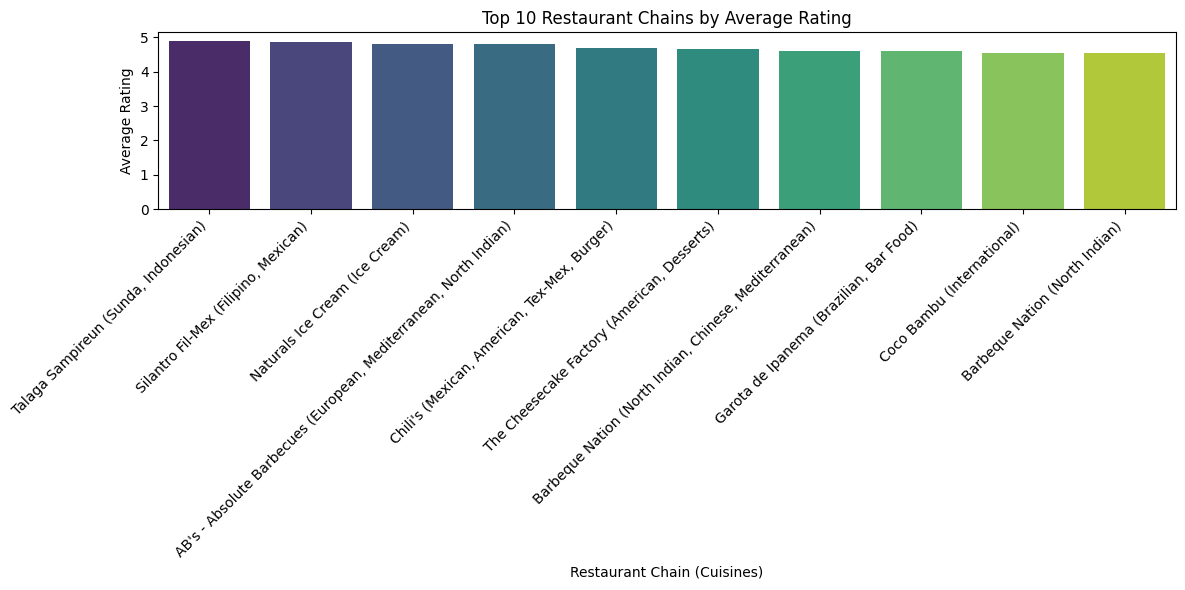

/tmp/ipython-input-2124154163.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Chain Identifier', y='Total Votes', data=top_n_by_votes, palette='magma')


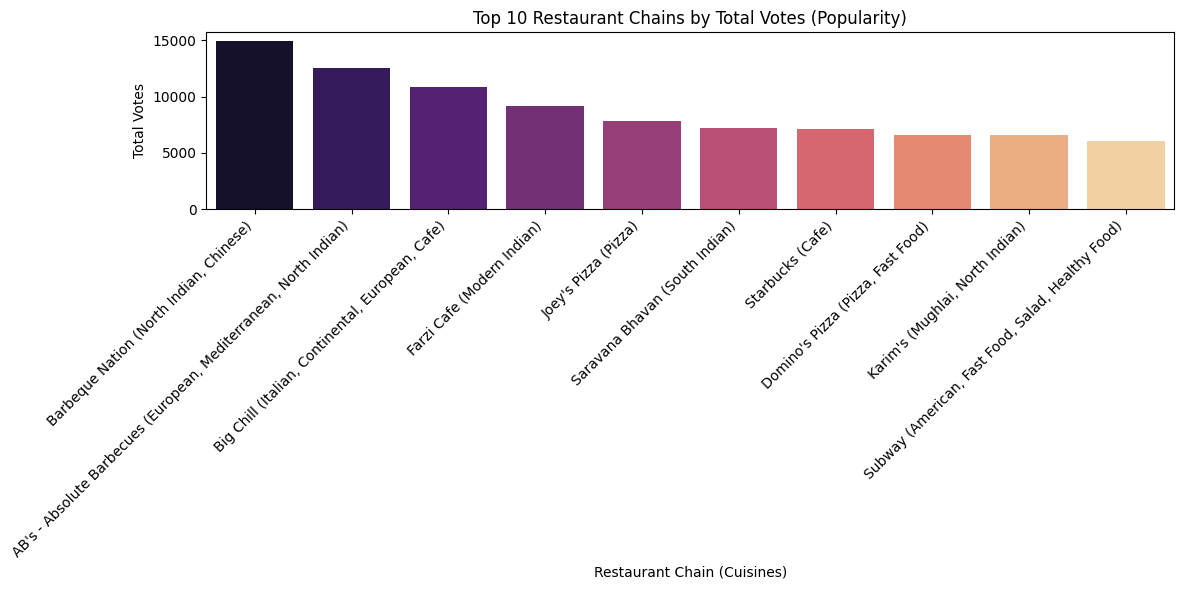

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

N = 10  # Number of top chains to visualize

# Prepare data for plotting
restaurant_chain_metrics['Chain Identifier'] = restaurant_chain_metrics['Restaurant Name'] + ' (' + restaurant_chain_metrics['Cuisines'] + ')'

# --- Top N by Average Rating ---
top_n_by_rating = restaurant_chain_metrics.sort_values(by='Average Rating', ascending=False).head(N)

plt.figure(figsize=(12, 6))
sns.barplot(x='Chain Identifier', y='Average Rating', data=top_n_by_rating, palette='viridis')
plt.title(f'Top {N} Restaurant Chains by Average Rating')
plt.xlabel('Restaurant Chain (Cuisines)')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Top N by Total Votes (Popularity) ---
top_n_by_votes = restaurant_chain_metrics.sort_values(by='Total Votes', ascending=False).head(N)

plt.figure(figsize=(12, 6))
sns.barplot(x='Chain Identifier', y='Total Votes', data=top_n_by_votes, palette='magma')
plt.title(f'Top {N} Restaurant Chains by Total Votes (Popularity)')
plt.xlabel('Restaurant Chain (Cuisines)')
plt.ylabel('Total Votes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

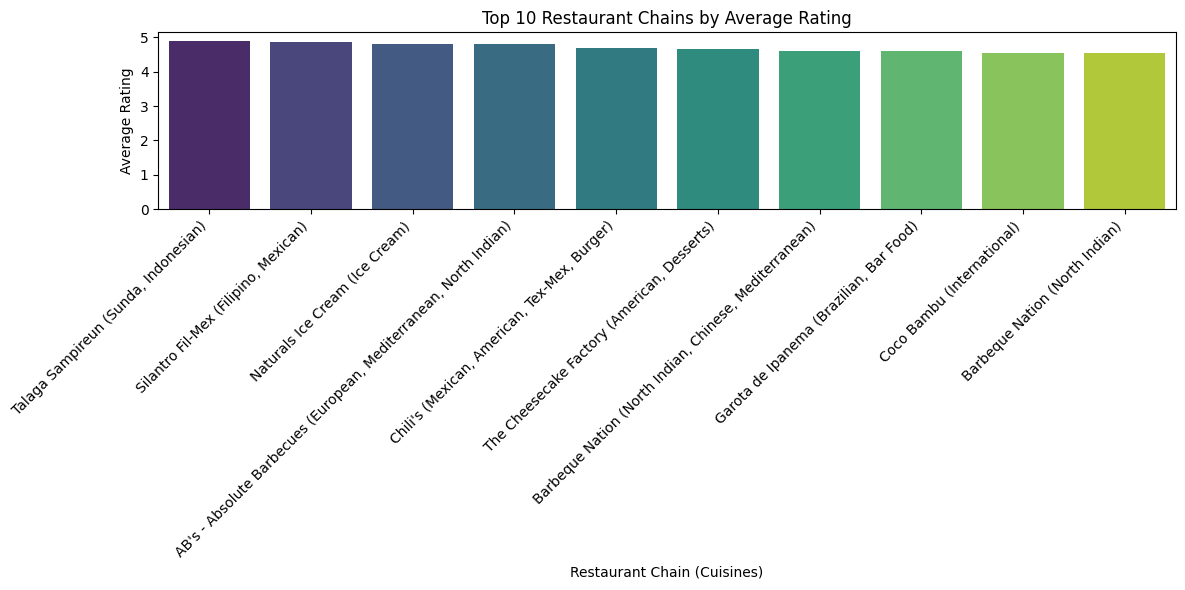

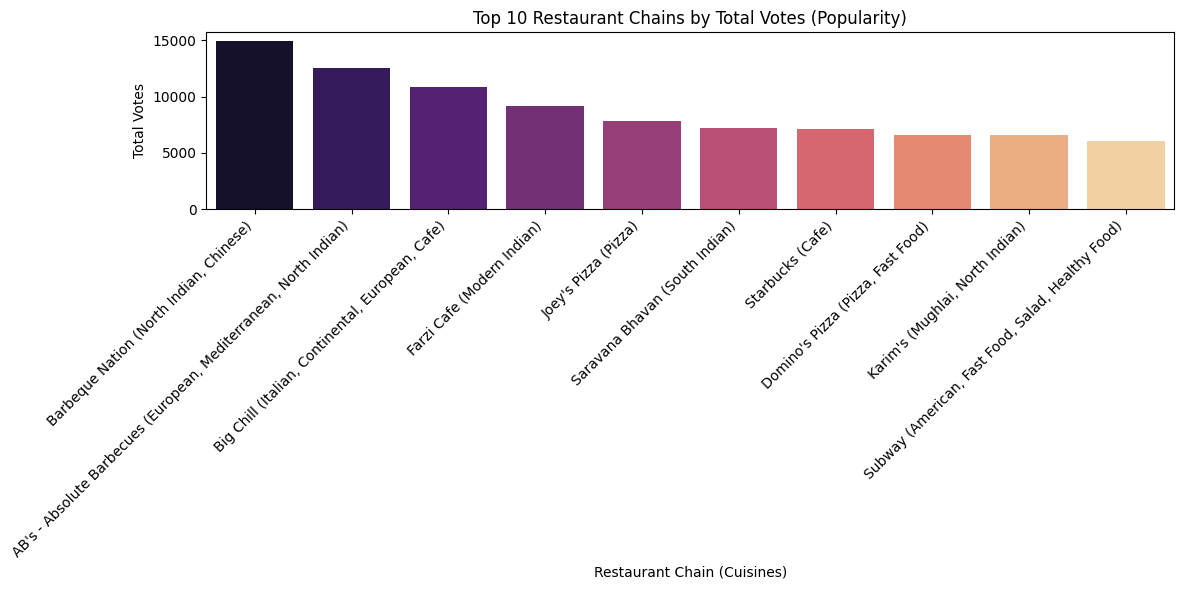

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

N = 10  # Number of top chains to visualize

# Prepare data for plotting
restaurant_chain_metrics['Chain Identifier'] = restaurant_chain_metrics['Restaurant Name'] + ' (' + restaurant_chain_metrics['Cuisines'] + ')'

# --- Top N by Average Rating ---
top_n_by_rating = restaurant_chain_metrics.sort_values(by='Average Rating', ascending=False).head(N)

plt.figure(figsize=(12, 6))
sns.barplot(x='Chain Identifier', y='Average Rating', data=top_n_by_rating, palette='viridis', hue='Chain Identifier', legend=False)
plt.title(f'Top {N} Restaurant Chains by Average Rating')
plt.xlabel('Restaurant Chain (Cuisines)')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Top N by Total Votes (Popularity) ---
top_n_by_votes = restaurant_chain_metrics.sort_values(by='Total Votes', ascending=False).head(N)

plt.figure(figsize=(12, 6))
sns.barplot(x='Chain Identifier', y='Total Votes', data=top_n_by_votes, palette='magma', hue='Chain Identifier', legend=False)
plt.title(f'Top {N} Restaurant Chains by Total Votes (Popularity)')
plt.xlabel('Restaurant Chain (Cuisines)')
plt.ylabel('Total Votes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the identified restaurant chains, their average ratings, and popularity metrics, highlighting any key insights or trends observed from the analysis and visualizations.


## Summary:



### Data Analysis Key Findings
*   Restaurant chains were successfully identified by grouping restaurants with the same 'Restaurant Name' and 'Cuisines' and having more than one location. For example, '10 Downing Street' was identified with 2 locations, and '34, Chowringhee Lane' with 11 locations.
*   For each identified chain, the 'Average Rating' and 'Total Votes' were calculated. For instance, '10 Downing Street' (North Indian, Chinese) with 2 locations has an 'Average Rating' of 4.0 and 'Total Votes' of 670.
*   'Number of Locations' and 'Total Votes' were confirmed as suitable metrics to represent the popularity of a restaurant chain.
*   Two bar charts were successfully generated to visualize the top 10 restaurant chains: one ranked by 'Average Rating' and another by 'Total Votes', providing clear visual insights into highly-rated and popular chains.

### Insights or Next Steps
*   Further analysis could explore the correlation between 'Number of Locations', 'Average Rating', and 'Total Votes' to understand if larger chains tend to have higher or lower ratings, or if more locations directly translate to higher vote counts.
*   Investigate the specific cuisines offered by the top-rated and most popular chains to identify successful culinary trends within the chain restaurant segment.
